# 서울 격자 단위 PM10 예측 시각화
**모델**: V5-base (HiddenExtension V5)  
아래 `날짜`와 `시간`을 바꿔서 원하는 시점의 PM10 분포를 확인하세요.

In [35]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.colors import LinearSegmentedColormap
warnings.filterwarnings('ignore')

# ── 한글 폰트 설정 ─────────────────────────────────────────────────────────
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
matplotlib.rc('font', family='NanumGothic')
matplotlib.rcParams['axes.unicode_minus'] = False

# ── 경로 설정 ──────────────────────────────────────────────────────────────
_cwd = os.getcwd()
if os.path.isfile(os.path.join(_cwd, 'config.py')):
    V5_DIR = _cwd
elif os.path.isfile(os.path.join(_cwd, 'HiddenExtension_V5', 'config.py')):
    V5_DIR = os.path.join(_cwd, 'HiddenExtension_V5')
else:
    V5_DIR = '/workspace/ST-GNN Modeling/HiddenExtension_V5'

GRID_NPY   = os.path.join(V5_DIR, 'checkpoints/V5-base/grid_pm10_test.npy')
GRID_CSV   = '/home/data/youngwoong/ST-GNN_Dataset/Data_Preprocessed/Land Use Regression/격자 기본/격자_250m_4326.csv'
GDIR       = '/home/data/youngwoong/ST-GNN_Dataset/Data_Preprocessed/Land Use Regression/격자 기본'
HIDDEN_DIR = os.path.join(V5_DIR, '../HiddenExtension_V1/data/hidden_vectors')

# ── 데이터 로드 ────────────────────────────────────────────────────────────
pm_grid      = np.load(GRID_NPY)           # (T, G)
grid_csv     = pd.read_csv(GRID_CSV)
lon          = grid_csv['lon'].values
lat          = grid_csv['lat'].values

ts_all       = np.load(os.path.join(GDIR, 'timestamps_all.npy'))
tidx         = np.load(os.path.join(GDIR, 'time_idx_test.npy'))
ts_test      = pd.to_datetime(ts_all[tidx[12:]])

coords_sta    = np.load(os.path.join(HIDDEN_DIR, 'coords.npy'))
station_names = np.load(os.path.join(HIDDEN_DIR, 'stations.npy'))
pm_station    = np.load(os.path.join(HIDDEN_DIR, 'pm_test.npy'))   # (T, N)

# ── 파란 컬러맵 ────────────────────────────────────────────────────────────
BLUE_CMAP = LinearSegmentedColormap.from_list('pm_blue', [
    '#f7fbff', '#deebf7', '#9ecae1', '#4292c6', '#2171b5', '#084594', '#03003d'
], N=256)

print(f'데이터 로드 완료')
print(f'테스트 기간: {ts_test[0].strftime("%Y-%m-%d")} ~ {ts_test[-1].strftime("%Y-%m-%d")}')
print(f'PM10 범위: {pm_grid.min():.1f} ~ {pm_grid.max():.1f} μg/m³')

데이터 로드 완료
테스트 기간: 2025-07-10 ~ 2025-10-31
PM10 범위: 4.5 ~ 68.9 μg/m³


In [36]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  원하는 날짜와 시간을 여기서 설정하세요
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
TARGET_DATE = '2025-08-15'
TARGET_HOUR = 9
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

target_ts = pd.Timestamp(f'{TARGET_DATE} {TARGET_HOUR:02d}:00:00')
t_idx     = np.abs(ts_test - target_ts).argmin()
ts_label  = ts_test[t_idx].strftime('%Y년 %m월 %d일  %H시')
pm_t      = pm_grid[t_idx]
pm_sta_t  = pm_station[t_idx]

print(f'선택 시점: {ts_label}')
print(f'격자 PM10: 평균 {pm_t.mean():.1f} / 최소 {pm_t.min():.1f} / 최대 {pm_t.max():.1f} μg/m³')

선택 시점: 2025년 08월 15일  09시
격자 PM10: 평균 25.8 / 최소 22.7 / 최대 29.6 μg/m³


In [37]:
import matplotlib.colors as mcolors

def plot_pm10(
    pm_vals, lon, lat, title='',
    vmin=None, vmax=None,
    coords_sta=None, pm_sta=None,
    station_names=None, show_labels=False,
    figsize=(10, 10), ax=None,
    mode='percentile',   # 'percentile' | 'power' | 'deviation' | 'absolute'
    gamma=0.4,           # power norm 강도 (낮을수록 저값 강조)
):
    """
    mode 설명:
      'percentile' : 해당 시점 p5~p95로 색 범위 설정 → 분포 차이 잘 보임 (기본)
      'power'      : 비선형 스케일로 저농도 차이 강조
      'deviation'  : 공간 평균으로부터의 편차를 색으로 표현
      'absolute'   : 절대값 고정 범위 (vmin/vmax 직접 지정)
    """
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=figsize, facecolor='white')
        ax.set_facecolor('white')

    # ── 모드별 norm/cmap 설정 ─────────────────────────────────────────────
    if mode == 'deviation':
        # 공간 평균 편차: 파란(낮음) ↔ 흰(평균) ↔ 진파랑(높음)
        dev = pm_vals - pm_vals.mean()
        plot_vals = dev
        lim = np.percentile(np.abs(dev), 97)
        v0, v1 = -lim, lim
        cmap = LinearSegmentedColormap.from_list('dev_blue', [
            '#f7fbff', '#9ecae1', '#ffffff', '#4292c6', '#03003d'
        ], N=256)
        norm = mcolors.Normalize(vmin=v0, vmax=v1)
        cbar_label = 'PM10 편차 (μg/m³)'
    elif mode == 'power':
        plot_vals = pm_vals
        v0 = vmin if vmin is not None else max(0, np.percentile(pm_vals, 2))
        v1 = vmax if vmax is not None else np.percentile(pm_vals, 98)
        norm = mcolors.PowerNorm(gamma=gamma, vmin=v0, vmax=v1)
        cmap = BLUE_CMAP
        cbar_label = 'PM10 (μg/m³)'
    elif mode == 'percentile':
        # 해당 시점 p5~p95로 범위 자동 조정
        plot_vals = pm_vals
        v0 = vmin if vmin is not None else np.percentile(pm_vals, 5)
        v1 = vmax if vmax is not None else np.percentile(pm_vals, 95)
        norm = mcolors.Normalize(vmin=v0, vmax=v1)
        cmap = BLUE_CMAP
        cbar_label = 'PM10 (μg/m³)'
    else:  # absolute
        plot_vals = pm_vals
        v0 = vmin if vmin is not None else 0
        v1 = vmax if vmax is not None else np.percentile(pm_vals, 98)
        norm = mcolors.Normalize(vmin=v0, vmax=v1)
        cmap = BLUE_CMAP
        cbar_label = 'PM10 (μg/m³)'

    # ── 격자 산점도 ────────────────────────────────────────────────────────
    sc = ax.scatter(
        lon, lat, c=plot_vals,
        cmap=cmap, norm=norm,
        s=3.5, linewidths=0, alpha=0.92, rasterized=True
    )

    cbar = plt.colorbar(sc, ax=ax, fraction=0.028, pad=0.02, shrink=0.75)
    cbar.set_label(cbar_label, fontsize=11, labelpad=8)
    cbar.ax.tick_params(labelsize=9)

    # ── 관측소 오버레이 ────────────────────────────────────────────────────
    if coords_sta is not None and pm_sta is not None:
        sta_lat, sta_lon = coords_sta[:, 0], coords_sta[:, 1]
        sta_vals = (pm_sta - pm_sta.mean()) if mode == 'deviation' else pm_sta
        ax.scatter(
            sta_lon, sta_lat, c=sta_vals,
            cmap=cmap, norm=norm,
            s=90, linewidths=1.8, edgecolors='white',
            marker='o', zorder=5
        )
        ax.scatter(sta_lon, sta_lat, c='white', s=14, linewidths=0, zorder=6)

        if show_labels and station_names is not None:
            for name, slon, slat in zip(station_names, sta_lon, sta_lat):
                ax.annotate(
                    name, (slon, slat),
                    fontsize=5.5, ha='center', va='bottom',
                    xytext=(0, 6), textcoords='offset points',
                    color='#1a1a2e',
                    bbox=dict(boxstyle='round,pad=0.1',
                              fc='white', ec='none', alpha=0.65)
                )

    ax.set_xlabel('경도', fontsize=10)
    ax.set_ylabel('위도', fontsize=10)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=14)
    ax.set_aspect('equal')
    ax.tick_params(labelsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(False)

    if standalone:
        plt.tight_layout()
        plt.show()
    return sc

print('플롯 함수 준비 완료 (mode: percentile / power / deviation / absolute)')

플롯 함수 준비 완료 (mode: percentile / power / deviation / absolute)


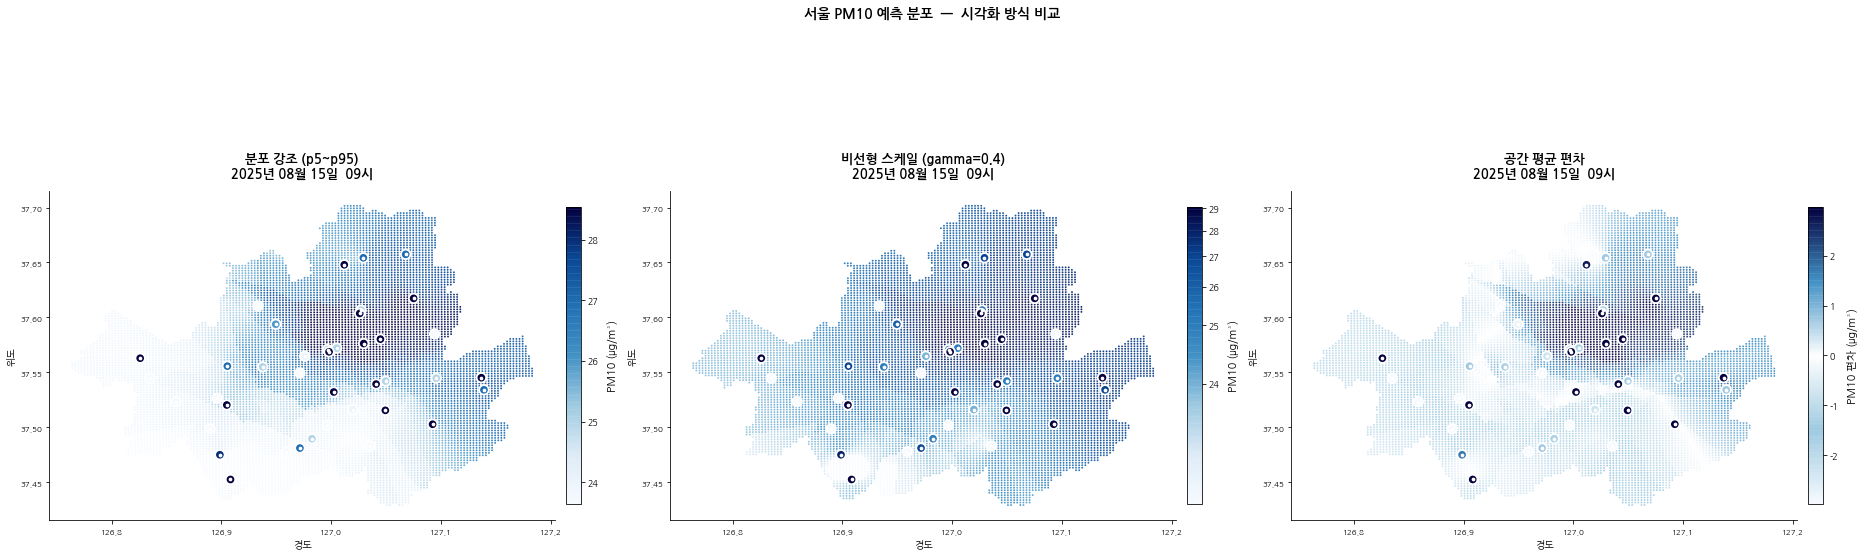


아래: percentile 모드 단독 (권장)


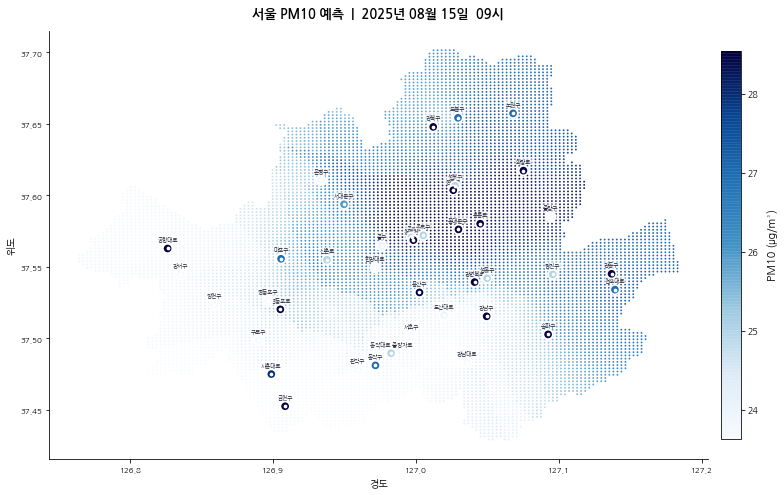

In [38]:
# ── 단일 시점 — 3가지 모드 비교 ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(26, 9), facecolor='white')
for ax in axes: ax.set_facecolor('white')

modes = [
    ('percentile', f'분포 강조 (p5~p95)\n{ts_label}'),
    ('power',      f'비선형 스케일 (gamma=0.4)\n{ts_label}'),
    ('deviation',  f'공간 평균 편차\n{ts_label}'),
]

for ax, (mode, title) in zip(axes, modes):
    plot_pm10(
        pm_vals      = pm_t,
        lon=lon, lat=lat,
        title        = title,
        coords_sta   = coords_sta,
        pm_sta       = pm_sta_t,
        station_names= station_names,
        show_labels  = False,
        mode         = mode,
        ax           = ax,
    )

plt.suptitle('서울 PM10 예측 분포  —  시각화 방식 비교', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── 가장 보기 좋은 방식 하나만 크게 ────────────────────────────────────────
print('\n아래: percentile 모드 단독 (권장)')
plot_pm10(
    pm_vals      = pm_t,
    lon=lon, lat=lat,
    title        = f'서울 PM10 예측  |  {ts_label}',
    coords_sta   = coords_sta,
    pm_sta       = pm_sta_t,
    station_names= station_names,
    show_labels  = True,
    mode         = 'percentile',
    figsize      = (11, 11),
)

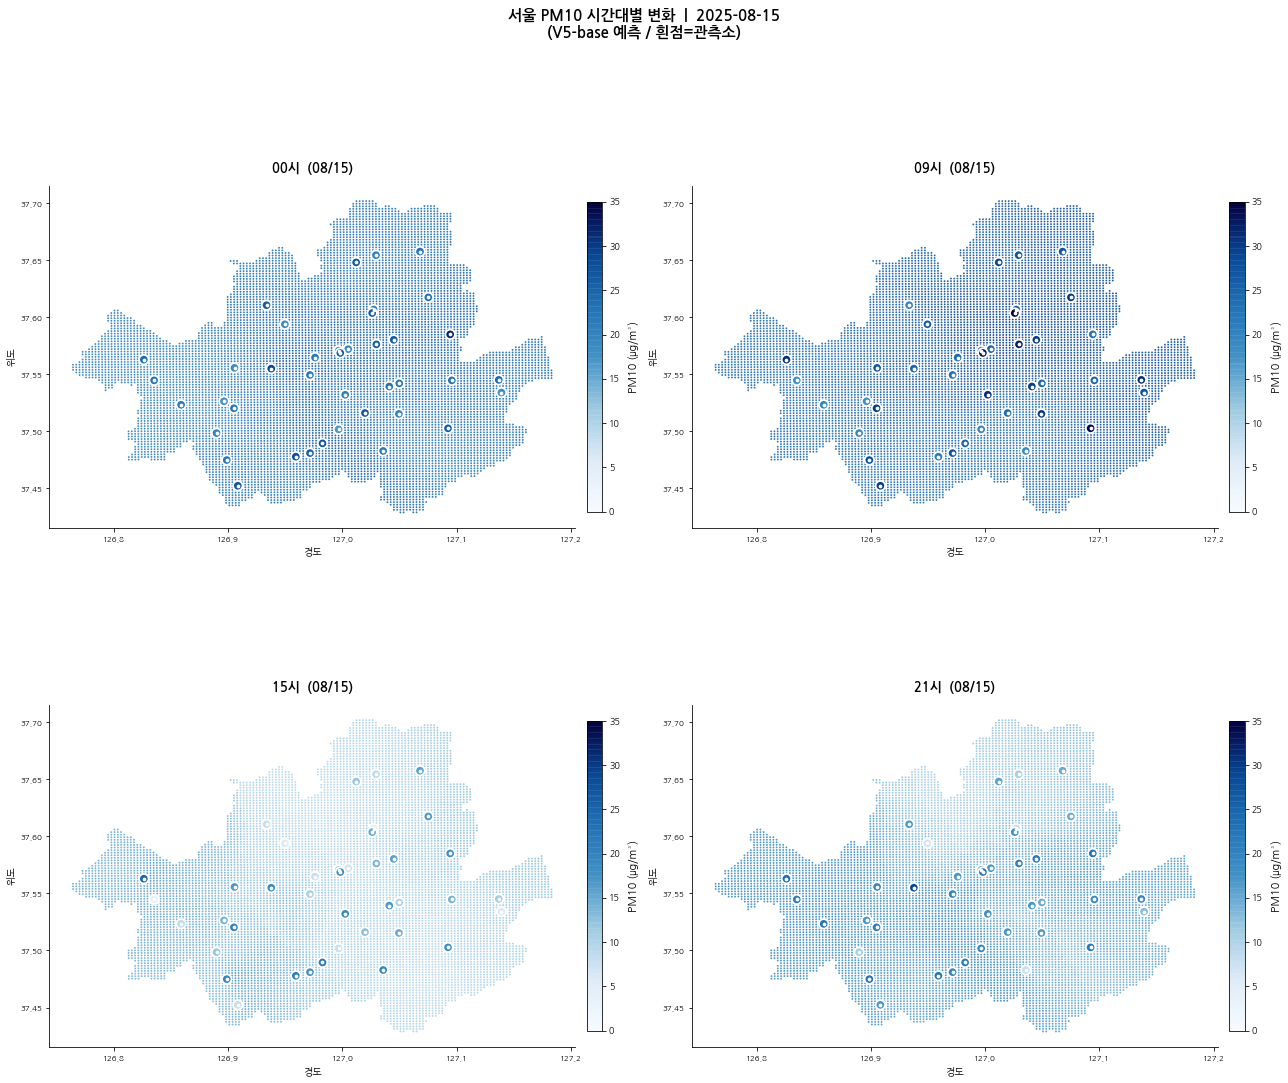

In [39]:
# ── 하루 시간대별 4개 스냅샷 ──────────────────────────────────────────────────
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SNAP_DATE  = '2025-08-15'
SNAP_HOURS = [0, 9, 15, 21]
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

snap_data = []
for h in SNAP_HOURS:
    ti = np.abs(ts_test - pd.Timestamp(f'{SNAP_DATE} {h:02d}:00:00')).argmin()
    snap_data.append((ti, pm_grid[ti], pm_station[ti],
                      ts_test[ti].strftime('%H시  (%m/%d)')))

vmax_day = max(np.percentile(pm_grid[[s[0] for s in snap_data]], 99),
               max(s[2].max() for s in snap_data))

fig, axes = plt.subplots(2, 2, figsize=(18, 16), facecolor='white')
for ax in axes.flat: ax.set_facecolor('white')
fig.suptitle(
    f'서울 PM10 시간대별 변화  |  {SNAP_DATE}\n(V5-base 예측 / 흰점=관측소)',
    fontsize=15, fontweight='bold', y=1.01
)

for ax, (ti, pm_h, pm_s, label) in zip(axes.flat, snap_data):
    sc = plot_pm10(
        pm_vals    = pm_h,
        lon=lon, lat=lat,
        title      = label,
        vmin       = 0, vmax=vmax_day,
        coords_sta = coords_sta,
        pm_sta     = pm_s,
        show_labels= False,
        ax         = ax,
    )

plt.tight_layout()
plt.show()

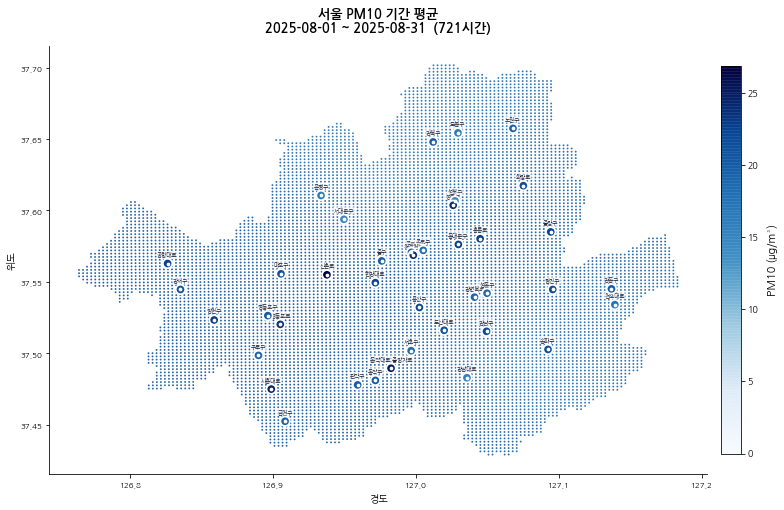

격자 평균: 19.68 μg/m³  /  관측소 평균: 20.61 μg/m³


In [40]:
# ── 기간 평균 지도 ──────────────────────────────────────────────────────────
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
MEAN_START = '2025-08-01'
MEAN_END   = '2025-08-31'
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

mask = (ts_test >= MEAN_START) & (ts_test <= MEAN_END)
if mask.sum() == 0:
    print('선택 기간에 데이터 없음')
else:
    pm_mean    = pm_grid[mask].mean(axis=0)
    pm_sta_avg = pm_station[mask].mean(axis=0)
    n_h        = mask.sum()

    plot_pm10(
        pm_vals      = pm_mean,
        lon=lon, lat=lat,
        title        = f'서울 PM10 기간 평균\n{MEAN_START} ~ {MEAN_END}  ({n_h}시간)',
        vmin         = 0,
        vmax         = max(np.percentile(pm_mean, 98), pm_sta_avg.max()),
        coords_sta   = coords_sta,
        pm_sta       = pm_sta_avg,
        station_names= station_names,
        show_labels  = True,
        figsize      = (11, 11),
    )
    print(f'격자 평균: {pm_mean.mean():.2f} μg/m³  /  관측소 평균: {pm_sta_avg.mean():.2f} μg/m³')

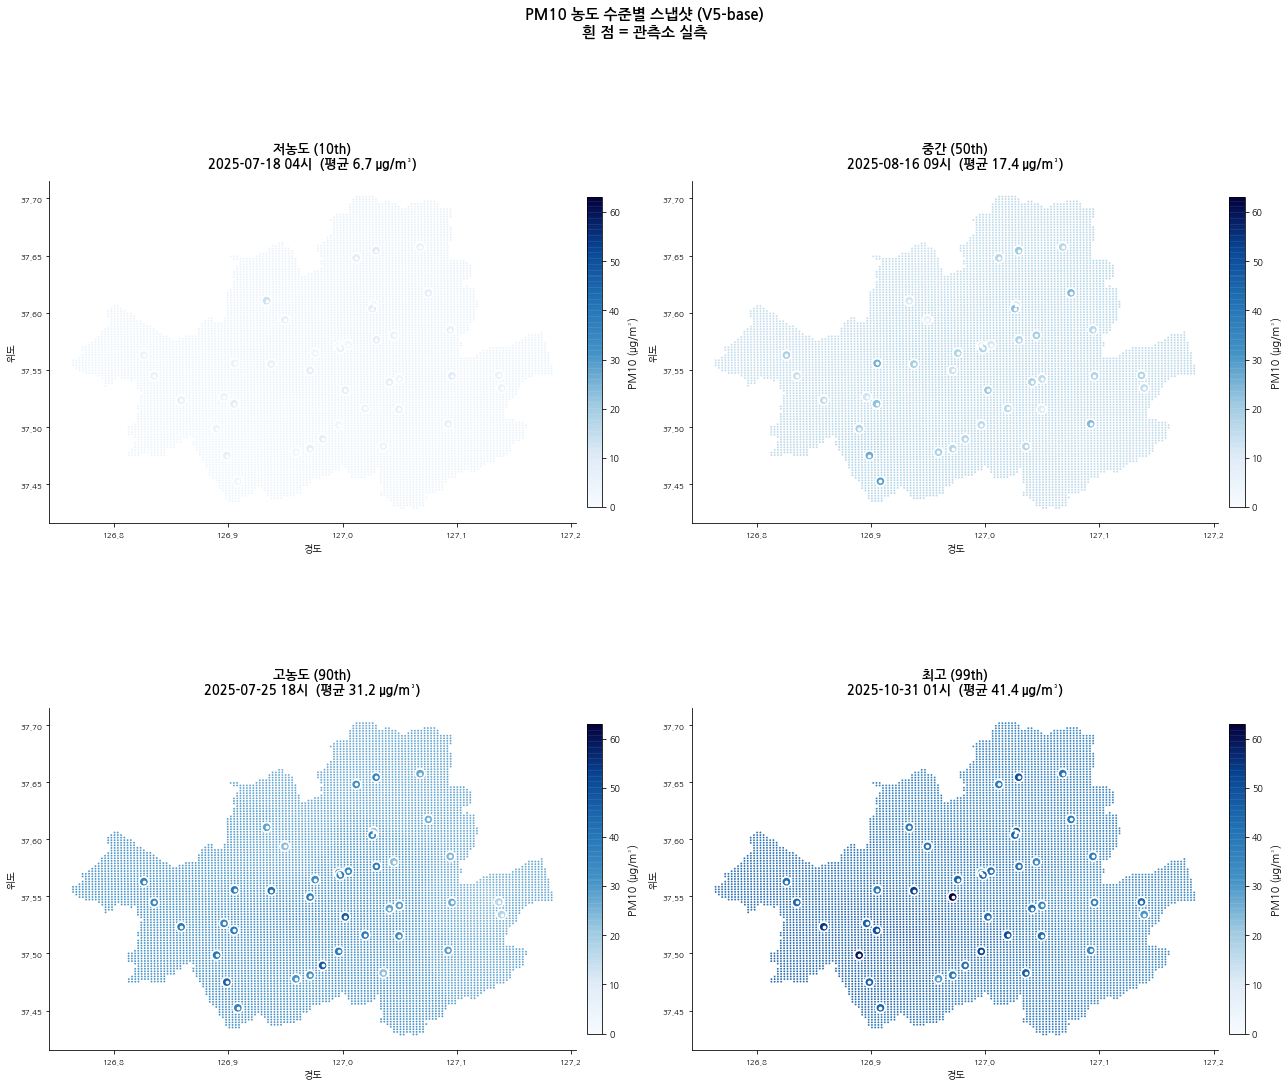

In [41]:
# ── 자동 극단 스냅샷 (저/중/고/극고 농도) ─────────────────────────────────────
hourly_mean = pm_grid.mean(axis=1)
pct_labels  = ['저농도 (10th)', '중간 (50th)', '고농도 (90th)', '최고 (99th)']
snap_idxs   = [np.argmin(np.abs(hourly_mean - np.percentile(hourly_mean, p)))
               for p in [10, 50, 90, 99]]

vmax_ext = max(
    np.percentile(pm_grid[snap_idxs], 99),
    max(pm_station[i].max() for i in snap_idxs)
)

fig, axes = plt.subplots(2, 2, figsize=(18, 16), facecolor='white')
for ax in axes.flat: ax.set_facecolor('white')
fig.suptitle(
    'PM10 농도 수준별 스냅샷 (V5-base)\n흰 점 = 관측소 실측',
    fontsize=15, fontweight='bold', y=1.01
)

for ax, ti, label in zip(axes.flat, snap_idxs, pct_labels):
    ts_str = ts_test[ti].strftime('%Y-%m-%d %H시')
    plot_pm10(
        pm_vals    = pm_grid[ti],
        lon=lon, lat=lat,
        title      = f'{label}\n{ts_str}  (평균 {hourly_mean[ti]:.1f} μg/m³)',
        vmin       = 0, vmax=vmax_ext,
        coords_sta = coords_sta,
        pm_sta     = pm_station[ti],
        show_labels= False,
        ax         = ax,
    )

plt.tight_layout()
plt.show()

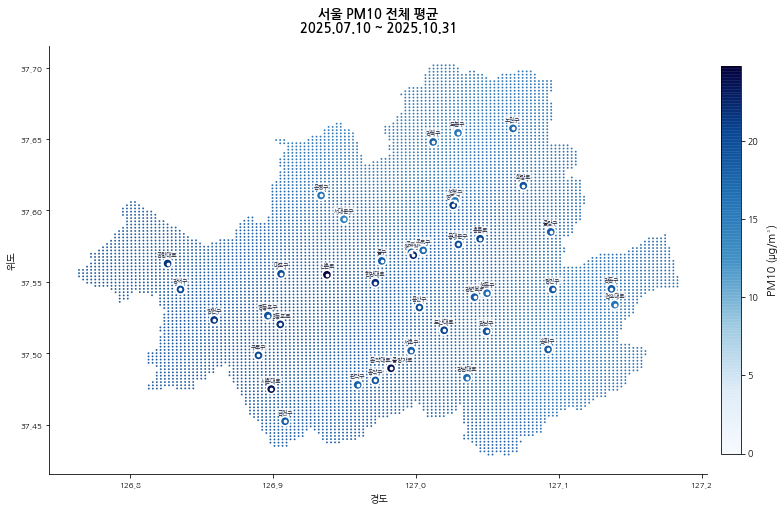

In [42]:
# ── 전체 테스트 기간 평균 ────────────────────────────────────────────────────
pm_total_mean = pm_grid.mean(axis=0)
pm_sta_total  = pm_station.mean(axis=0)

plot_pm10(
    pm_vals      = pm_total_mean,
    lon=lon, lat=lat,
    title        = f'서울 PM10 전체 평균\n{ts_test[0].strftime("%Y.%m.%d")} ~ {ts_test[-1].strftime("%Y.%m.%d")}',
    vmin         = 0,
    vmax         = max(np.percentile(pm_total_mean, 99), pm_sta_total.max()),
    coords_sta   = coords_sta,
    pm_sta       = pm_sta_total,
    station_names= station_names,
    show_labels  = True,
    figsize      = (11, 11),
)